Supervised Learning (iPython Notebook)
=================================

In this notebook we will perform supervised learning using two algorithms:
- kNN
- Decision Trees

We will then analyze the performance using accuracy metrics.

## Helper Function for Visualization

First of all, we define the following helper function for visualization. Note that the internals are **not** relevant for us.

In [33]:
# helper for visualizing the classifiers...
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

# Create color maps (maximum of 9 colors)
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF', '#AAFFFF', '#FFAAFF', '#FFFFAA', '#FAFAFA', '#AFAFAF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF', '#00FFFF', '#FF00FF', '#FFFF00', '#F0F0F0', '#0F0F0F'])

# visualize a classifier: hand over the classifier, the input data (X), the labels (y),
# a title for the diagram and (optional) the boundary for the plot
def visualize_classifier(classifier, X, y, title, boundary = None):
    # Define the minimum and maximum values for X and Y
    # that will be used in the mesh grid
    if boundary is None or len(boundary) < 4:
        min_x, max_x = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0 
        min_y, max_y = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0
    else:
        min_x, max_x = boundary[0], boundary[1]
        min_y, max_y = boundary[2], boundary[3]

    if boundary is not None:
        # Define the step size to use in plotting the mesh grid 
        mesh_step_size = 0.01 
        # Define the mesh grid of X and Y values 
        x_vals, y_vals = np.meshgrid(np.arange(min_x, max_x, mesh_step_size), np.arange(min_y, max_y, mesh_step_size))

        # Run the classifier on the mesh grid 
        output = classifier.predict(np.c_[x_vals.ravel(), y_vals.ravel()]) 
        # Reshape the output array 
        output = output.reshape(x_vals.shape)

        # Create a plot 
        plt.figure() 
        # Choose a color scheme for the plot 
        plt.pcolormesh(x_vals, y_vals, output, cmap=cmap_light)
        # Overlay the training points on the plot
    plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolor='k', linewidth=1, cmap=cmap_bold)

    if boundary is not None:
        # Specify the boundaries of the plot 
        plt.xlim(x_vals.min(), x_vals.max()) 
        plt.ylim(y_vals.min(), y_vals.max()) 
    # Specify the ticks on the X and Y axes
    plt.xticks((np.arange(int(min_x), int(max_x), 1.0)))
    plt.yticks((np.arange(int(min_y), int(max_y), 1.0)))
    plt.title(title)
    plt.show()
    plt.gcf().clear()

## Loading Data

Next, we prepare a data set and split it into a training and a test set. To get a better impression of the data we visualize it using the above helper method.

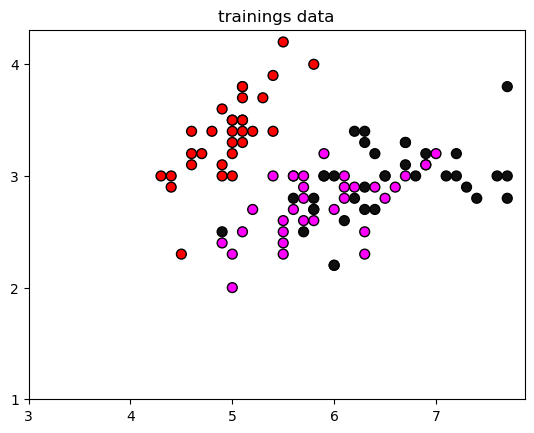

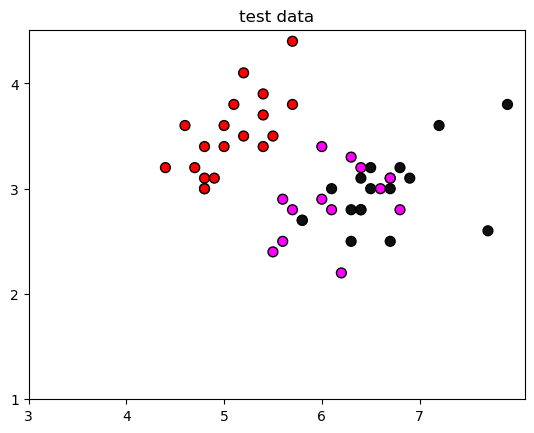

<Figure size 640x480 with 0 Axes>

In [34]:
from sklearn import neighbors, datasets
from sklearn.model_selection import train_test_split

# import some data to play with
iris = datasets.load_iris()

# we only take the first two features. We could avoid this ugly
# slicing by using a two-dim dataset
X = iris.data[:, :2]
y = iris.target

# split data (67% training, 33% test)
train_data, test_data, train_labels, test_labels = train_test_split(
    X, y, test_size=0.33, random_state=42)

# visualize data
visualize_classifier(None, train_data, train_labels, "trainings data")
visualize_classifier(None, test_data, test_labels, "test data")

Nearest Neighbor Classification
-----------------------------------------------
The principle behind nearest neighbor methods is to find a predefined number of training samples closest in distance to the new point, and predict the label from these. The number of samples can be a user-defined constant (k-nearest neighbor learning), or vary based on the local density of points (radius-based neighbor learning). The distance can, in general, be any metric measure: standard Euclidean distance is the most common choice. Neighbors-based methods are known as non-generalizing machine learning methods, since they simply “remember” all of its training data.

Despite its simplicity, nearest neighbors has been successful in a large number of classification and regression problems, including handwritten digits and satellite image scenes. Being a non-parametric method, it is often successful in classification situations where the decision boundary is very irregular.

Neighbors-based classification is a type of instance-based learning or non-generalizing learning: it does not attempt to construct a general internal model, but simply stores instances of the training data. Classification is computed from a simple majority vote of the nearest neighbors of each point: a query point is assigned the data class which has the most representatives within the nearest neighbors of the point.

The sklearn package provides different nearest neighbors classifiers. KNeighborsClassifier implements learning based on the k nearest neighbors of each query point, where k is an integer value specified by the user. The k-neighbors classification in KNeighborsClassifier is the most commonly used technique. The optimal choice of the value k is highly data-dependent: in general a larger k suppresses the effects of noise, but makes the classification boundaries less distinct.

In cases where the data is not uniformly sampled, radius-based neighbors classification in RadiusNeighborsClassifier can be a better choice. The user specifies a fixed radius r, such that points in sparser neighborhoods use fewer nearest neighbors for the classification. For high-dimensional parameter spaces, this method becomes less effective due to the so-called "curse of dimensionality".

The basic nearest neighbors classification uses uniform weights: that is, the value assigned to a query point is computed from a simple majority vote of the nearest neighbors. Under some circumstances, it is better to weight the neighbors such that nearer neighbors contribute more to the fit. This can be accomplished through the weights keyword. The default value, weights = 'uniform', assigns uniform weights to each neighbor. weights = 'distance' assigns weights proportional to the inverse of the distance from the query point. Alternatively, a user-defined function of the distance can be supplied to compute the weights.

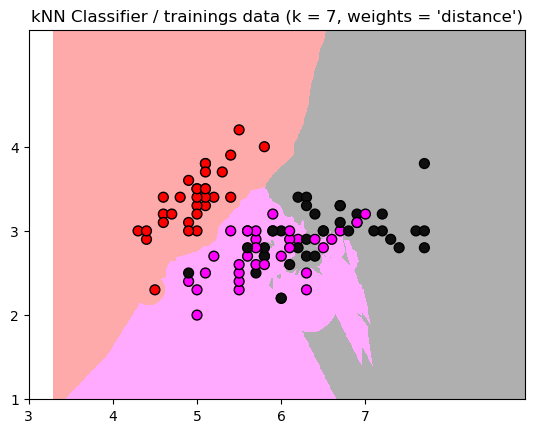

<Figure size 640x480 with 0 Axes>

In [35]:
from sklearn import neighbors, datasets
from sklearn.model_selection import train_test_split

# we set k to 7
n_neighbors = 7

# import some data to play with
iris = datasets.load_iris()

# we only take the first two features. We could avoid this ugly
# slicing by using a two-dim dataset
X = iris.data[:, :2]
y = iris.target

# split data (67% training, 33% test)
train_data, test_data, train_labels, test_labels = train_test_split(
    X, y, test_size=0.33, random_state=42)

# we create an instance of kNN Classifier and fit the data.
knn_clf = neighbors.KNeighborsClassifier(n_neighbors, weights='distance')
knn_clf.fit(train_data, train_labels)

# define boundary for visualize_classifier
boundary = []
if len(X) > 0:
    boundary.append(X[:, 0].min() - 1.0)
    boundary.append(X[:, 0].max() + 1.0)
    boundary.append(X[:, 1].min() - 1.0)
    boundary.append(X[:, 1].max() + 1.0)

# visualize the kNN Classifier for the training data
visualize_classifier(knn_clf, train_data, train_labels,
                     "kNN Classifier / trainings data (k = %d, weights = 'distance')" % n_neighbors, boundary)

Decision trees
---------------------

A Decision Tree is a structure that allows us to split the dataset into branches and then make simple decisions at each level. This will allow us to arrive at the final decision by walking down the tree. Decision Trees are produced by training algorithms, which identify how we can split the data in the best possible way.

Any decision process starts at the root node at the top of the tree. Each node in the tree is basically a decision rule. Algorithms construct these rules based on the relationship between the input data and the target labels in the training data. The values in the input data are utilized to estimate the value for the output.

Now that we understand basic concept of Decision Trees, the next thing is to understand how the trees are automatically constructed. We need algorithms that can construct the optimal tree based on our data. In order to understand it, we need to understand the concept of entropy. In this context, entropy refers to information entropy and not thermodynamic entropy. Entropy is basically a measure of uncertainty. One of the main goals of a decision tree is to reduce uncertainty as we move from the root node towards the leaf nodes. When we see an unknown data point, we are completely uncertain about the output. By the time we reach the leaf node, we are certain about the output. This means that we need to construct the decision tree in a way that will reduce the uncertainty at each level. This implies that we need to reduce the entropy as we progress down the tree.

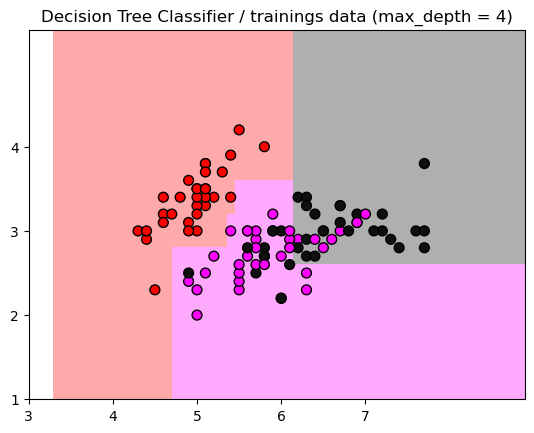

<Figure size 640x480 with 0 Axes>

In [36]:
# Load additional libraries
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree classifier (max. depth set to 4)
params = {'random_state': 0, 'max_depth': 4}
dt_clf = DecisionTreeClassifier(**params)
dt_clf.fit(train_data, train_labels)

# visualize the DT Classifier for the training data
visualize_classifier(dt_clf, train_data, train_labels,
                     "Decision Tree Classifier / trainings data (max_depth = %d)" % 4, boundary)

Performance Assessment for a Classification Model
-----------------------------------------------------------------------------

Starting point: We create a classification model using any technique (examples see above).

#### Confusion matrix
A Confusion matrix is a figure or a table that is used to describe the performance of a classifier. It is usually extracted from a test dataset for which the ground truth is known. We compare each class with every other class and see how many samples are misclassified. During the construction of this table, we actually come across several key metrics that are very important in the field of machine learning.

Let's consider a binary classification case where the output is either 0 or 1:
* **True positives:** These are the samples for which we predicted 1 as the output and the ground truth is 1 too.
* **True negatives:** These are the samples for which we predicted 0 as the output and the ground truth is 0 too.
* **False positives:** These are the samples for which we predicted 1 as the output but the ground truth is 0. This is also known as a Type I error.
* **False negatives:** These are the samples for which we predicted 0 as the output but the ground truth is 1. This is also known as a Type II error.

Depending on the problem at hand, we may have to optimize our algorithm to reduce the false positive or the false negative rate. For example, in a biometric identification system, it is very important to avoid false positives, because the wrong people might get access to sensitive information. Let's see how to create a confusion matrix.

#### Quality measures and cross-validation for a classification model

Measures to evaluate the quality of a machine learning technique (precision, recall, accuracy and F1 are the most important ones):

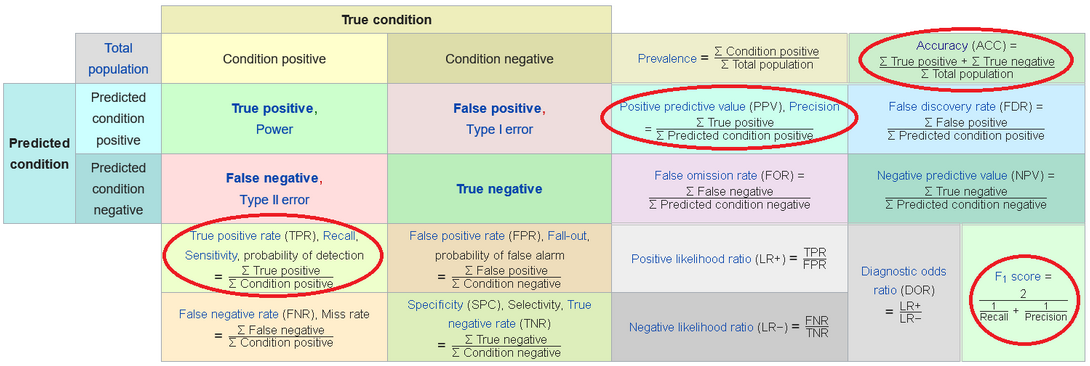

In [39]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Define sample labels
true_labels = test_labels
print("True labels:",true_labels)
pred_labels = dt_clf.predict(test_data)
print("Predicted labels:",pred_labels)

# A simple way to validate the model: predict classes for test data and subtract test labels
print('Predicted classes minus test labels:', pred_labels-test_labels)
# all values that are not equal to zero are errors (wrong classification)

True labels: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0 1 2 2 1 2]
Predicted labels: [1 0 1 1 2 0 1 2 1 1 2 0 1 0 0 2 2 1 1 2 0 1 0 2 2 2 1 2 0 0 0 0 2 0 0 1 2
 0 0 0 1 1 2 0 0 1 2 2 2 2]
Predicted classes minus test labels: [ 0  0 -1  0  1  0  0  0  0  0  0  0  1  0  0  1  0  0  0  0  0 -1  0  0
  0  0 -1  0  0  0  0  0  1  0  0 -1  1  0  0  0 -1  0  1  0  0  0  0  0
  1  0]



               precision    recall  f1-score   support

     Class-0       1.00      0.95      0.97        19
     Class-1       0.60      0.60      0.60        15
     Class-2       0.65      0.69      0.67        16

    accuracy                           0.76        50
   macro avg       0.75      0.74      0.75        50
weighted avg       0.77      0.76      0.76        50



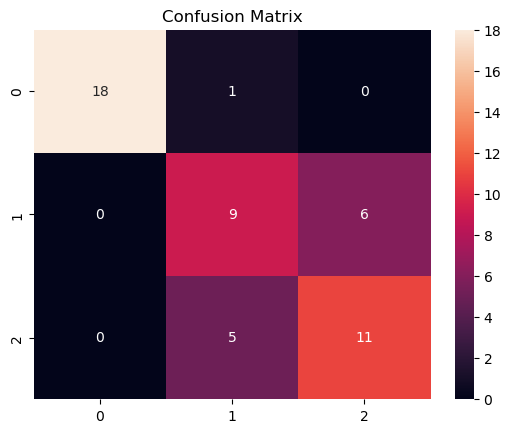

In [40]:
# Create confusion matrix
confusion_mat = confusion_matrix(true_labels, pred_labels)

import seaborn as sns

# visualize confusion matrix (incl. title and labels)
ax = plt.subplot()
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
sns.heatmap(confusion_mat, annot=True, ax = ax)

# Classification report (as created by sklearn)
targets = ['Class-0', 'Class-1', 'Class-2']
print('\n', classification_report(true_labels, pred_labels, target_names=targets))

Calculating quality measures through cross-validation:

In [41]:
from sklearn import model_selection

# Compute accuracy of the classifier manually
accuracy = 100.0 * (true_labels == pred_labels).sum() / test_data.shape[0]
print("Accuracy of the new classifier on test set =", round(accuracy, 2), "%")

# this defines the cross-validation strategy (cv parameter)
num_folds = 3
# 3 means: 3 folds (sets) for cross-validation

# Scoring functions of sklearn (original data: X and y!)
accuracy_values = model_selection.cross_val_score(knn_clf, 
        X, y, scoring='accuracy', cv=num_folds)
print("All accuracy values: ", accuracy_values)
print("Accuracy: " + str(round(100*accuracy_values.mean(), 2)) + "%")

precision_values = model_selection.cross_val_score(knn_clf, 
        X, y, scoring='precision_weighted', cv=num_folds)
print("Precision: " + str(round(100*precision_values.mean(), 2)) + "%")

recall_values = model_selection.cross_val_score(knn_clf, 
        X, y, scoring='recall_weighted', cv=num_folds)
print("Recall: " + str(round(100*recall_values.mean(), 2)) + "%")

f1_values = model_selection.cross_val_score(knn_clf, 
        X, y, scoring='f1_weighted', cv=num_folds)
print("F1: " + str(round(100*f1_values.mean(), 2)) + "%")

Accuracy of the new classifier on test set = 76.0 %
All accuracy values:  [0.76 0.82 0.78]
Accuracy: 78.67%
Precision: 80.61%
Recall: 78.67%
F1: 77.96%


### Exercise 9.1: Build a k-Nearest-Neighbour (k=7) as well as a Decision Tree classifier (max.depth=4) and train it with the following data (X = input, y = labels, 70% of data for training). Visualize the prediction models on the basis of the trainings and test data-set. Calculate the accuracy of these two models.

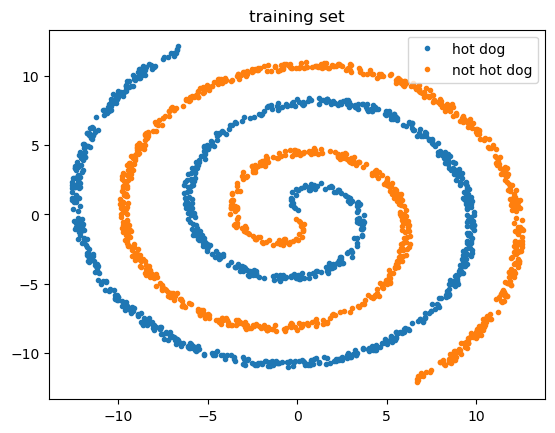

In [42]:
def twospirals(n_points, noise=.5):
    """
     Returns the two spirals dataset.
    """
    n = np.sqrt(np.random.rand(n_points,1)) * 780 * (2*np.pi)/360
    d1x = -np.cos(n)*n + np.random.rand(n_points,1) * noise
    d1y = np.sin(n)*n + np.random.rand(n_points,1) * noise
    return (np.vstack((np.hstack((d1x,d1y)),np.hstack((-d1x,-d1y)))), 
            np.hstack((np.zeros(n_points),np.ones(n_points))))

X, y = twospirals(1000)

plt.title('training set')
plt.plot(X[y==0,0], X[y==0,1], '.', label='hot dog')
plt.plot(X[y==1,0], X[y==1,1], '.', label='not hot dog')
plt.legend()
plt.show()